# LendingClub PD – Data Wrangling, Outlier Study & Feature Engineering

**Purpose:** Single source of truth for PD (Probability of Default) inputs. We:
1. Load and wrangle LoanStats3a-style data (target definition, missing values, types).
2. Run an **outlier study** (distributions, caps/winsorization) to avoid leakage and stabilize models.
3. Build **15 high-impact features** via `credit_risk.feature_engineering.common_features` (shared by XGBoost and quantum PD models).
4. Save a cleaned, feature-level dataset for downstream training notebooks.

**Data:** Place `LoanStats3a.csv` (or equivalent) under `data/credit_risk_pd/LendingClub/`. Columns expected: `loan_amnt`, `int_rate`, `installment`, `grade`, `emp_length`, `annual_inc`, `dti`, `delinq_2yrs`, `revol_util`, `revol_bal`, `open_acc`, `total_acc`, `inq_last_6mths`, `loan_status`; FICO from `fico_range_low` / `fico_range_high` if present.

## 1. Setup and load raw data

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# Repo root (run from repo root or from notebooks/)
ROOT = Path(".").resolve() if (Path(".").resolve() / "credit_risk").exists() else Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR = ROOT / "data" / "credit_risk_pd" / "LendingClub"
OUTPUT_DIR = DATA_DIR / "processed"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# LoanStats3a CSV often has 2 header rows and a footer; skipfooter can be used if needed
csv_path = DATA_DIR / "LoanStats3a.csv"
if not csv_path.exists():
    # Fallback: any CSV in folder (e.g. from Kaggle)
    csvs = list(DATA_DIR.glob("*.csv"))
    csv_path = csvs[0] if csvs else None

if csv_path is None or not csv_path.exists():
    raise FileNotFoundError("Place LoanStats3a.csv (or a LendingClub CSV) under data/credit_risk_pd/LendingClub/")

df_raw = pd.read_csv(csv_path, skiprows=1, low_memory=False)
# Remove footer row if present ("Total amount funded" etc.)
df_raw = df_raw[~df_raw.iloc[:, 0].astype(str).str.contains("Total", na=False)]
print(f"Loaded {len(df_raw):,} rows. Columns: {list(df_raw.columns[:20])}...")

Loaded 42,536 rows. Columns: ['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc']...


## 2. Target definition (binary default)

LendingClub `loan_status` includes: Current, Fully Paid, Charged Off, Late, In Grace Period, etc. We define **default = 1** for Charged Off (and optionally severe delinquency); **non-default = 0** for Fully Paid (and optionally Current). For PD we typically use only **Fully Paid** vs **Charged Off** to avoid censoring.

In [2]:
col_status = "loan_status"
if col_status not in df_raw.columns:
    col_status = [c for c in df_raw.columns if "status" in c.lower()][0] if any("status" in c.lower() for c in df_raw.columns) else None
if col_status is None:
    raise ValueError("No loan_status column found")

df_raw["loan_status"] = df_raw[col_status].astype(str).str.strip()
# Bank-grade: Default = Charged Off, Default, Late (31-120); Non-default = Fully Paid only; drop ambiguous
default_statuses = {"Charged Off", "Default", "charged off", "default", "Late (31-120 days)", "late (31-120 days)"}
paid_statuses = {"Fully Paid", "fully paid"}

mask_default = df_raw["loan_status"].isin(default_statuses)
mask_paid = df_raw["loan_status"].isin(paid_statuses)
df = df_raw[mask_default | mask_paid].copy()
df["default"] = mask_default[mask_default | mask_paid].astype(int)
print(df["default"].value_counts())
print(f"Retained {len(df):,} rows with binary target (default vs fully paid only; ambiguous dropped).")

default
0    34116
1     5670
Name: count, dtype: int64
Retained 39,786 rows with binary target (default vs fully paid only; ambiguous dropped).


## 3. Column mapping and types (for common_features)

`common_features.build_features_from_dict` expects snake_case keys: `annual_inc`, `loan_amnt`, `int_rate`, `installment`, `dti`, `delinq_2yrs`, `revol_util`, `revol_bal`, `open_acc`, `total_acc`, `inq_last_6mths`, `emp_length`, `grade`, and optionally `fico_low`/`fico_high`. LoanStats CSV may use `fico_range_low` / `fico_range_high` — we normalize names.

In [3]:
rename = {
    "fico_range_low": "fico_low",
    "fico_range_high": "fico_high",
}
for old, new in rename.items():
    if old in df.columns and new not in df.columns:
        df = df.rename(columns={old: new})

# Coerce numeric columns (handle % and commas)
numeric_cols = ["loan_amnt", "int_rate", "installment", "annual_inc", "dti", "delinq_2yrs",
                "revol_util", "revol_bal", "open_acc", "total_acc", "inq_last_6mths", "fico_low", "fico_high"]
for c in numeric_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c].astype(str).str.replace("%", "").str.replace(",", ""), errors="coerce")
print("Numeric columns coerced.")

Numeric columns coerced.


### 3b. Leakage exclusion (drop post-origination and LC risk columns)

Drop columns that would leak the answer or are not known at origination: funded_amnt, funded_amnt_inv, total_pymnt, recoveries, collection_recovery_fee, out_prncp, last_pymnt_amnt, grade, sub_grade, int_rate.

In [4]:
COLS_LEAKAGE = ["funded_amnt", "funded_amnt_inv", "total_pymnt", "recoveries", "collection_recovery_fee",
                "out_prncp", "last_pymnt_amnt", "grade", "sub_grade", "int_rate"]
drop_cols = [c for c in COLS_LEAKAGE if c in df.columns]
df = df.drop(columns=drop_cols, errors="ignore")
print(f"Dropped leakage columns: {drop_cols}")

Dropped leakage columns: ['funded_amnt', 'funded_amnt_inv', 'total_pymnt', 'recoveries', 'collection_recovery_fee', 'out_prncp', 'last_pymnt_amnt', 'grade', 'sub_grade', 'int_rate']


## 4. Missing values and outlier study

We report missing rates for key variables, then inspect distributions and define **caps/winsorization** so that extreme values do not dominate the model. Typical choices: cap `annual_inc`, `revol_util`, `dti` at high percentiles; treat missing FICO or DTI as a separate risk signal where appropriate.

In [5]:
key_cols = [c for c in (numeric_cols + ["emp_length"]) if c in df.columns]
missing = df[key_cols].isna().mean().sort_values(ascending=False)
print("Missing rate (key columns):")
print(missing[missing > 0].to_string())

# Outlier caps (percentile-based; adjust for your use case)
caps = {
    "annual_inc": (None, 1e7),
    "revol_util": (0, 100),
    "dti": (0, 50),
    "open_acc": (0, 50),
    "inq_last_6mths": (0, 20),
}
for col, (lo, hi) in caps.items():
    if col in df.columns and hi is not None:
        df[col] = df[col].clip(lower=lo or df[col].min(), upper=hi)
print("\nOutlier caps applied.")

Missing rate (key columns):
emp_length    0.027095
revol_util    0.001257

Outlier caps applied.


### 4b. Time-based split (out-of-time validation)

Train: 2007–2015, Validation: 2016, Test: 2017–2018 (by issue_d). Mirrors how a model would be deployed.

In [6]:
if "issue_d" not in df.columns:
    df["split"] = "train"
    print("No issue_d column; all rows assigned to train.")
else:
    from datetime import datetime
    def parse_issue_d(s):
        if pd.isna(s) or s == "": return None
        try: return datetime.strptime(str(s).strip(), "%b-%Y")
        except ValueError: return None
    df["issue_dt"] = df["issue_d"].apply(parse_issue_d)
    df["issue_year"] = df["issue_dt"].dt.year
    df["split"] = "train"
    df.loc[df["issue_year"] == 2016, "split"] = "val"
    df.loc[df["issue_year"] >= 2017, "split"] = "test"
    df.loc[df["issue_dt"].isna(), "split"] = "train"
    print(df["split"].value_counts().sort_index().to_string())

split
train    39786


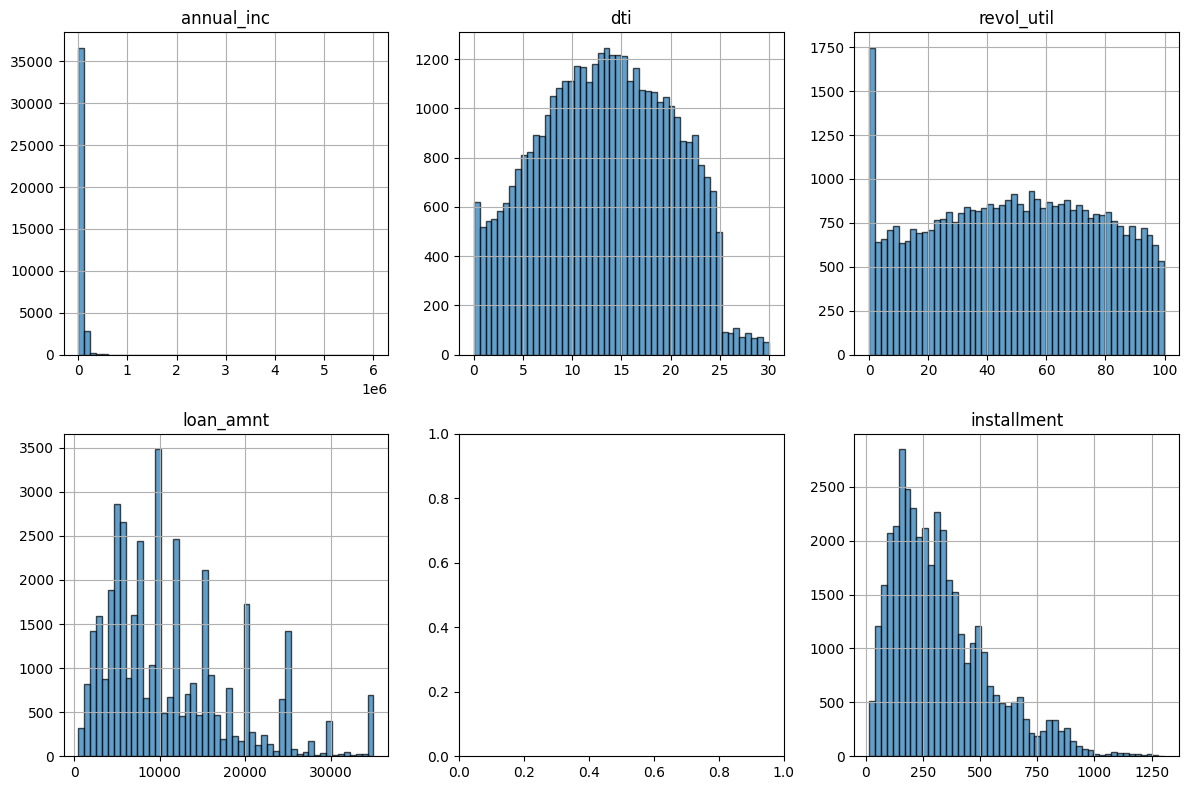

In [7]:
# Quick distribution plots (optional; comment out if no matplotlib)
try:
    import matplotlib.pyplot as plt
    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    for ax, col in zip(axes.flat, ["annual_inc", "dti", "revol_util", "loan_amnt", "fico_mid" if "fico_mid" in df.columns else "fico_low", "installment"]):
        if col in df.columns:
            df[col].dropna().hist(ax=ax, bins=50, edgecolor="black", alpha=0.7)
            ax.set_title(col)
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"Plots skipped: {e}")

## 5. Build no-leakage PD features (common_features)

We use **origination-only** features (no grade, sub_grade, int_rate) via `build_features_from_dataframe_no_leakage` so training mirrors production and avoids leakage.

In [8]:
from credit_risk.feature_engineering.common_features import (
    build_features_from_dataframe_no_leakage,
    get_feature_names_no_leakage,
)

X_raw = df.copy()
X_feat = build_features_from_dataframe_no_leakage(X_raw)
feature_names = get_feature_names_no_leakage()
print(f"{len(feature_names)} no-leakage features:", feature_names)
print(X_feat.describe().round(3).to_string())

19 no-leakage features: ['dti_ratio', 'dti_to_income', 'installment_to_income', 'payment_to_income_monthly', 'fico_mid', 'revol_util_pct', 'revol_util_bucket', 'loan_to_income', 'emp_months', 'delinq_flag', 'inq_6m', 'acc_util', 'revol_bal_log', 'fico_subprime', 'dti_high', 'credit_history_months', 'purpose_risk_code', 'home_ownership_risk_code', 'purpose_x_home_ownership']
       dti_ratio  dti_to_income  installment_to_income  payment_to_income_monthly  fico_mid  revol_util_pct  revol_util_bucket  loan_to_income  emp_months  delinq_flag     inq_6m   acc_util  revol_bal_log  fico_subprime   dti_high  credit_history_months  purpose_risk_code  home_ownership_risk_code  purpose_x_home_ownership
count  39786.000      39786.000              39786.000                  39786.000       0.0       39736.000          39736.000       39786.000   38708.000    39786.000  39786.000  39786.000      39786.000        39786.0  39786.000              39786.000          39786.000                 39786.000

## 6. Fill NaN and attach target

Fill remaining NaNs in features with median (or 0 for flags) so that tree and quantum models receive numeric inputs only.

In [9]:
for c in X_feat.columns:
    if X_feat[c].isna().any():
        if "flag" in c or "high" in c or "subprime" in c:
            X_feat[c] = X_feat[c].fillna(0.0)
        else:
            X_feat[c] = X_feat[c].fillna(X_feat[c].median())

X_feat["default"] = df["default"].values
X_feat["split"] = df["split"].values
out_path = OUTPUT_DIR / "lendingclub_engineered.parquet"
X_feat.to_parquet(out_path, index=False)
print(f"Saved engineered dataset to {out_path} ({len(X_feat):,} rows, {len(feature_names)} features + target + split).")

c:\Users\leemi\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Saved engineered dataset to C:\Users\leemi\OneDrive\Desktop\Job_search_2026\ocr-agentic-rag\data\credit_risk_pd\LendingClub\processed\lendingclub_engineered.parquet (39,786 rows, 19 features + target + split).


## 7. Summary

- **Target:** default = 1 (Charged Off, Default, Late 31–120 days), non-default = 0 (Fully Paid only); ambiguous statuses dropped.
- **Leakage exclusion:** dropped funded_amnt, funded_amnt_inv, total_pymnt, recoveries, collection_recovery_fee, out_prncp, last_pymnt_amnt, grade, sub_grade, int_rate.
- **Time-based split (out-of-time):** train 2007–2015, val 2016, test 2017–2018 by `issue_d`.
- **No-leakage features** from `common_features` (origination-only); NaNs filled; saved with `split` and `default` to `lendingclub_engineered.parquet`.
- Downstream notebooks should filter by `split` (train/val/test) and use `get_feature_names_no_leakage()` for training and evaluation.